In [1]:
using LinearAlgebra, Statistics
using CSV, DataFrames, JLD2
using QuantumOptics
using CairoMakie
include("src/NonHermitianRydbergAtomArray.jl")
using .NonHermitianRydbergAtomArray

# Figure 1 (B) & S15

## Long-Time Many-Body Correlations

Evolve the 10-atom chain across a logarithmic sweep of $V/\Gamma$ and calculate the connected correlations $C^x$, $C^y$, and $C^z$. Averaging over $\Gamma t=50$–$200$ isolates the long-time correlation structure used in Figure 1(B) and Figure S15.

In [ ]:
# Parallel-Computing Setup

using Distributed
addprocs(15)
@everywhere using LinearAlgebra, Statistics
@everywhere using CSV, DataFrames, JLD2
@everywhere using QuantumOptics
@everywhere using CairoMakie
@everywhere include("src/NonHermitianRydbergAtomArray.jl")
@everywhere using .NonHermitianRydbergAtomArray

In [ ]:
Γ = 1
Ω = 1.2Γ
V_ratios = 10 .^ collect(-2:0.01:1)
t_list = 0:0.1:200
Na = 10

@everywhere function run_corr_point(Vr, Na, Ω, Γ, t_list)
    model = build_model(Na = Na, interaction = :C3, sector = :full_hilbert)

    res = dynamics_nh( t_list, model, Ω, Vr * Γ, Γ; exports = :wavefunction)

    avg_idx = findall(t -> 50 <= Γ * t <= 200, t_list)

    ψ_window = @view res[:wavefunction][:, avg_idx]
    psi_t = [Ket(model.basis, ψ) for ψ in eachcol(ψ_window)]
    Cx, Cy, Cz = correlations(model, psi_t; connected = true)
    
    print("finished Vr = $Vr\n")

    return (mean(Cx), mean(Cy), mean(Cz))
end

out = pmap(Vr -> run_corr_point(Vr, Na, Ω, Γ, collect(t_list)), V_ratios)

Cx_avg = [x[1] for x in out]
Cy_avg = [x[2] for x in out]
Cz_avg = [x[3] for x in out]

jldsave("data/correlations_time_averaged.jld2";
    Na=Na, Γ=Γ, Ω_ratio=Ω/Γ, V_ratios=V_ratios, t_window = [50,200],
    Cx_avg=Cx_avg, Cy_avg=Cy_avg, Cz_avg=Cz_avg
)

      From worker 6:	finished Vr = 0.01096478196143185
      From worker 8:	finished Vr = 0.01148153621496883
      From worker 4:	finished Vr = 0.010471285480508996
      From worker 15:	finished Vr = 0.013489628825916533
      From worker 14:	finished Vr = 0.013182567385564075
      From worker 16:	finished Vr = 0.013803842646028845
      From worker 2:	finished Vr = 0.010000000000000002
      From worker 13:	finished Vr = 0.012882495516931342
      From worker 3:	finished Vr = 0.010232929922807542
      From worker 10:	finished Vr = 0.012022644346174132
      From worker 7:	finished Vr = 0.011220184543019636
      From worker 11:	finished Vr = 0.012302687708123818
      From worker 12:	finished Vr = 0.012589254117941675
      From worker 5:	finished Vr = 0.010715193052376065
      From worker 9:	finished Vr = 0.011748975549395297
      From worker 15:	finished Vr = 0.015848931924611134
      From worker 2:	finished Vr = 0.0162181009735893
      From worker 13:	finished Vr = 0.016595

301-element Vector{Float64}:
 0.12957300439148672
 0.12963448825762988
 0.12963798223678474
 0.12958433617607928
 0.12947498881156574
 0.12931200288389988
 0.12909808380102614
 0.12883657411631314
 0.12853141466872672
 0.12818706386423404
 0.12780837048104401
 0.12740040301376038
 0.12696824888907773
 ⋮
 0.004199516943121903
 0.004080395146285164
 0.0039633944848274354
 0.0038484980988508833
 0.003735691116562141
 0.0036249605595878023
 0.003516295235739353
 0.0034096856187203666
 0.0033051237145487198
 0.0032026029147659263
 0.0031021178368195023
 0.00300366415232499

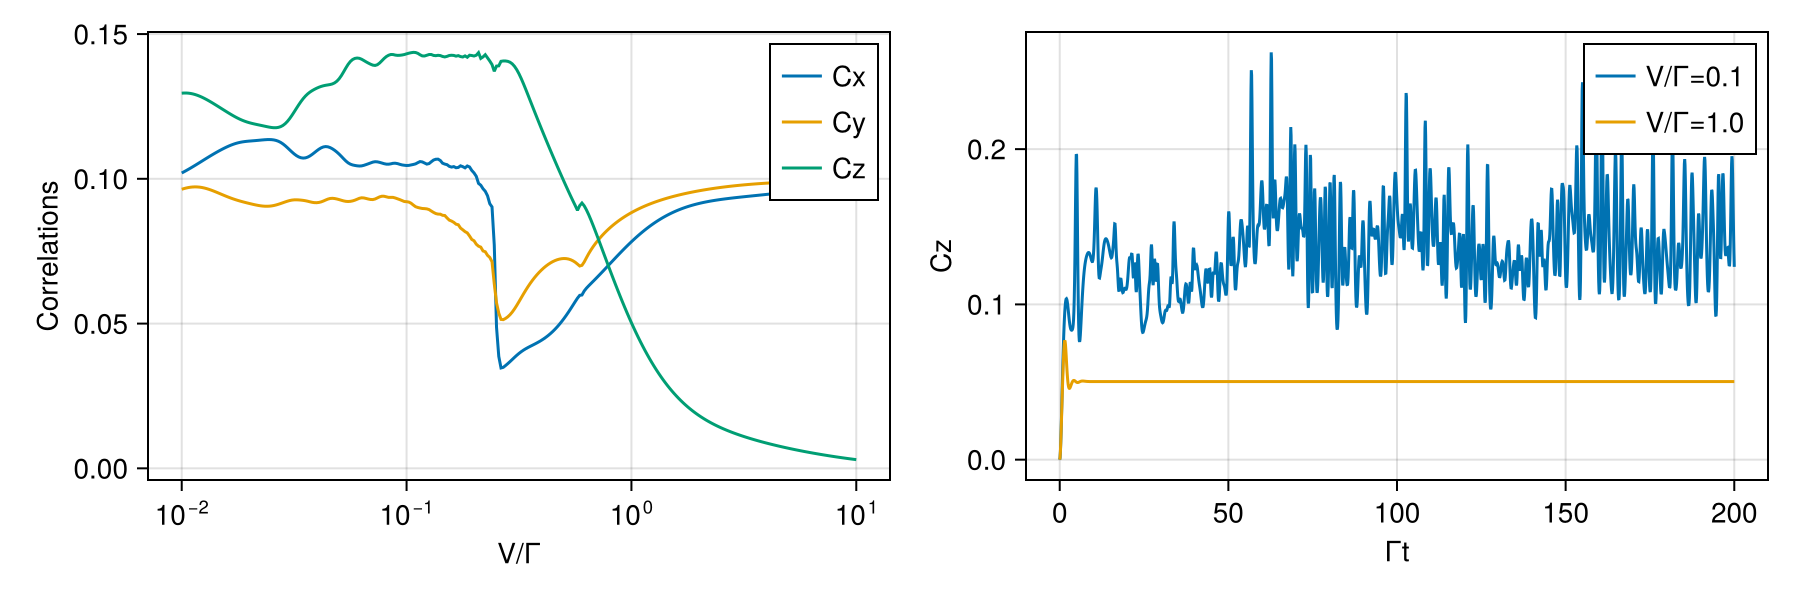

In [ ]:
data = load("data/correlations_time_averaged.jld2")

Na = data["Na"]
Γ = data["data"]
Ω_ratio = data["Ω_ratio"] * Γ
t_list = 0:0.1:200

model = build_model(Na=Na, interaction=:C3, sector=:full_hilbert)

res = dynamics_nh(t_list, model, Ω, 0.1 * Γ, Γ; exports=:wavefunction)
psi_t = [Ket(model.basis, psi) for psi in eachcol(res[:wavefunction])]
_,_, Cz_1 = correlations(model, psi_t; connected=true)

res = dynamics_nh(t_list, model, Ω, 1 * Γ, Γ; exports=:wavefunction)
psi_t = [Ket(model.basis, psi) for psi in eachcol(res[:wavefunction])]
_,_, Cz_2 = correlations(model, psi_t; connected=true)

fig = Figure(size=(900, 300))
ax1 = Axis(fig[1, 1], xlabel="V/Γ", ylabel="Correlations", xscale=log10)
lines!(ax1, data["V_ratios"], data["Cx_avg"], label="Cx")
lines!(ax1, data["V_ratios"], data["Cy_avg"], label="Cy")
lines!(ax1, data["V_ratios"], data["Cz_avg"], label="Cz")
axislegend(ax1)

ax2 = Axis(fig[1, 2], xlabel="Γt", ylabel="Cz")
lines!(ax2, Γ * t_list, Cz_1, label="V/Γ=0.1")
lines!(ax2, Γ * t_list, Cz_2, label="V/Γ=1.0")
axislegend(ax2)
fig

# Figure 2 (C-H)

## Nearly Non-Interacting Two-Atom Dynamics

Compare measured and simulated Loschmidt Echo dynamics for negligible interaction at three driving strengths. The raw and globally rescaled echoes distinguish damped PT-symmetric oscillations from the monotonic behavior of the PT-symmetry-broken phase.


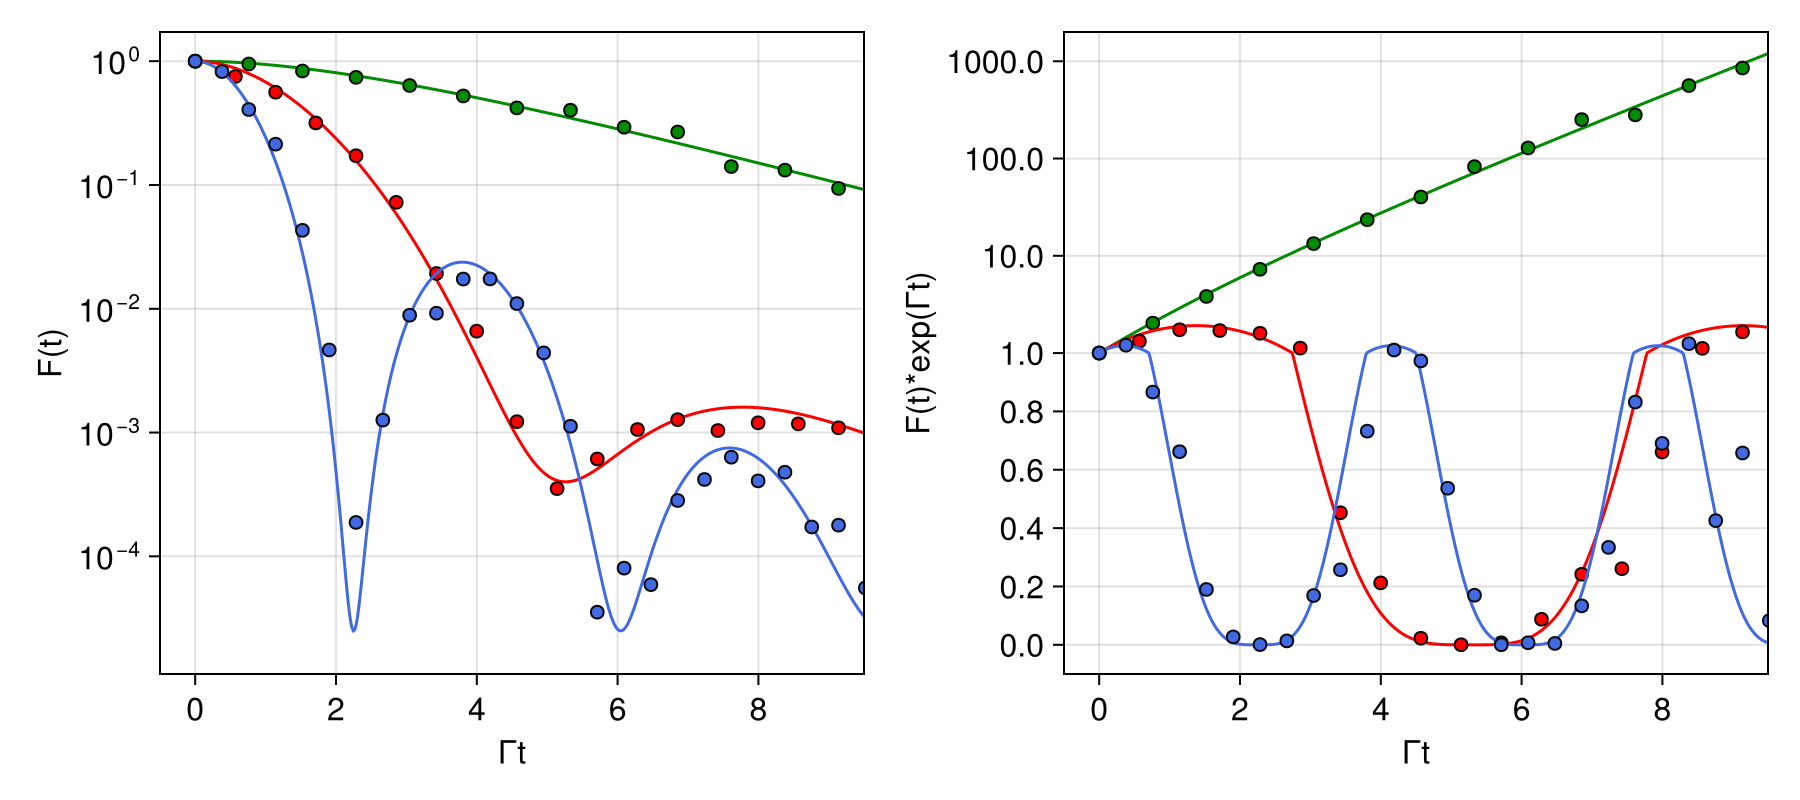

In [253]:
Γ = 2π * 6.06 * 0.5;
Ω = [0.38Γ  0.95Γ   1.73Γ];
ϵ = [0.005   0.02   0.005]; # background noise in the experiment

# Load experiment data
files = ["V_0_Omega_0.4.csv";
         "V_0_Omega_0.95_R.csv";
         "V_0_Omega_1.73_R.csv"];

t_sim = 0:0.001:0.6;
Ns = 2000;

forward(y) = y <= 1 ? y : 1 + log10(y) / 3
inverse(y) = y <= 1 ? y : 10.0^(3 * (y - 1))
linear_log = Makie.ReversibleScale(forward, inverse; limits=(0, 1000), name=:linear_log)

fig = Figure(size=(900,400), fontsize=16)
ax1 = Axis(fig[1, 1], xlabel="Γt", ylabel="F(t)", yscale = log10, limits=((-0.5,9.5),nothing))
ax2 = Axis(
    fig[1, 2], xlabel="Γt", ylabel="F(t)*exp(Γt)", 
    yscale=linear_log, limits=((-0.5,9.5),(-0.1,2e3)), yticks=[0,0.2,0.4,0.6,0.8, 1, 10, 100, 1000]
)
clrs = [:green4 :red :royalblue :gray];
for i = 1:3

    t, y_mean, y_std, p0 = counting_single("data/" * files[i])
    R = dynamics_nh(t_sim, model_nh(1), Ω[i], 0.0, Γ; exports = (:fidelity, :lognorm))
    R_fid = R[:fidelity] .* exp.(2*R[:lognorm])
    R_corr = (1 - ϵ[i]) * R_fid .+ ϵ[i];

    lines!(ax1,   Γ * t_sim, R_corr.^2, color=clrs[i], label="")
    scatter!(ax1, Γ * t, y_mean.^2; color=clrs[i], strokecolor=:gray4, strokewidth=1, label="") # Correct
    
    lines!(ax2, Γ * t_sim, R_fid.^2 .* exp.(Γ*t_sim), color=clrs[i], label="")
    scatter!(ax2, Γ * t,   ((y_mean .- ϵ[i])./ (1-ϵ[i])).^2 .* exp.(Γ*t) ; color=clrs[i], strokecolor=:gray4, strokewidth=1, label="") # Correct
end

fig

## Two atom dynamics with varying $\Omega$

At fixed $V/\Gamma=0.73$, compare the experimental and simulated two-atom Loschmidt Echo for several values of $\Omega/\Gamma$. The scaled echo reveals how tuning the coherent drive carries the system across the exceptional point.

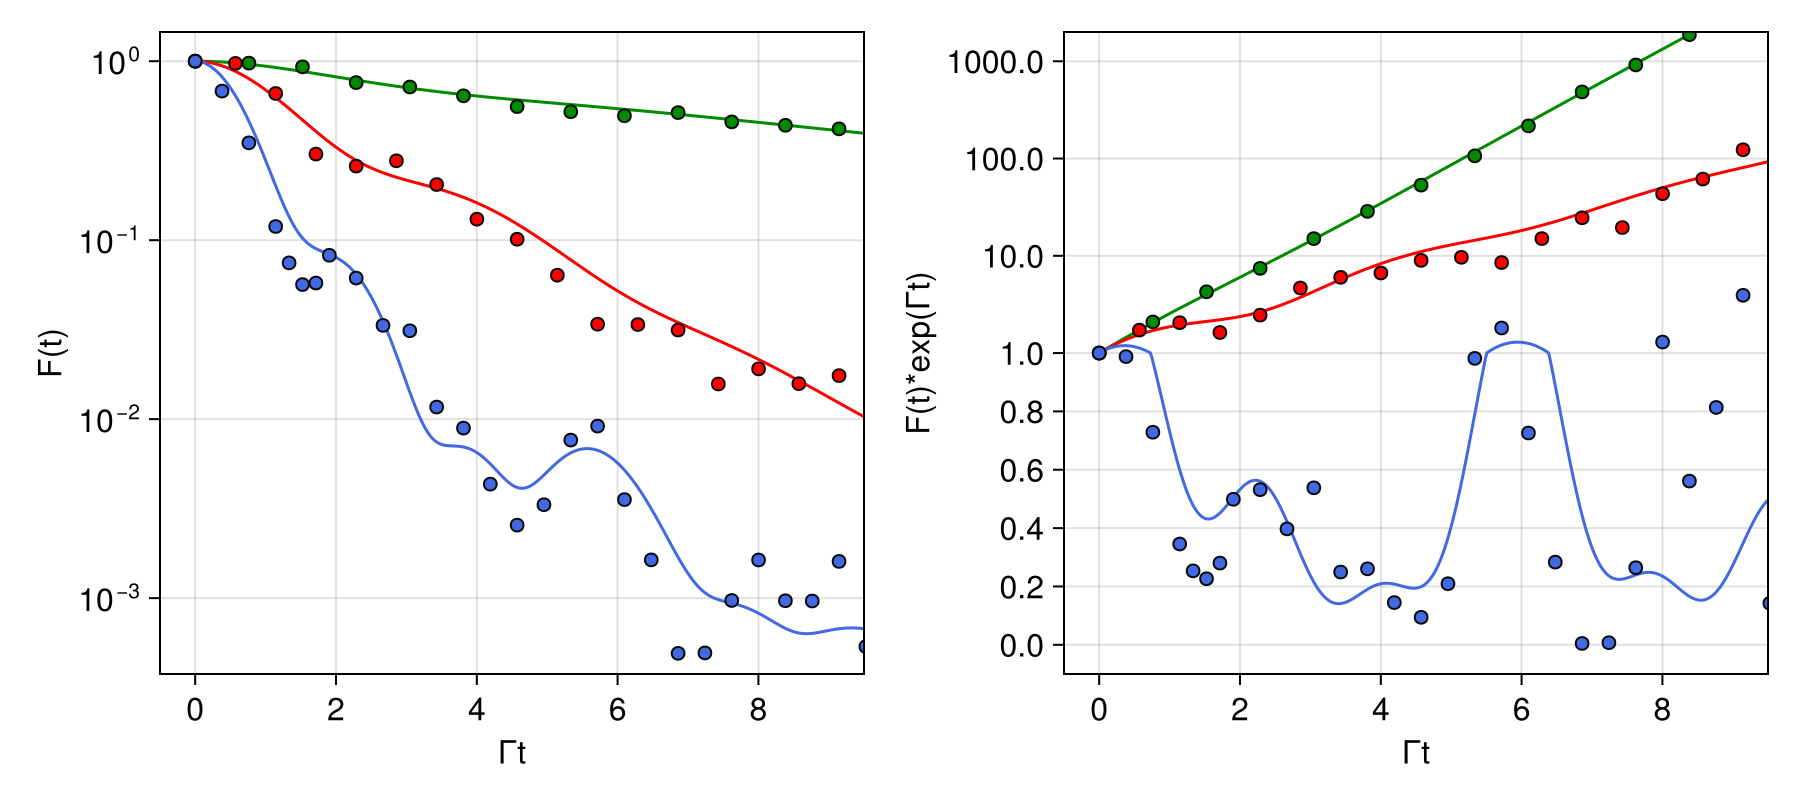

In [252]:
Γ = 2π * 6.065 * 0.5;
Ω = [0.4Γ   0.95Γ   1.73Γ];
V = [0.73Γ  0.73Γ   0.73Γ];
ϵ = [0.02   0.02    0.02]; # background noise in the experiment

# Load experiment data
files = ["V_0.73_Omega_0.4.csv";
         "V_0.73_Omega_0.95.csv";
         "V_0.73_Omega_1.73.csv"];


t_sim = 0:0.001:0.6;
Ns = 2000;

forward(y) = y <= 1 ? y : 1 + log10(y) / 3
inverse(y) = y <= 1 ? y : 10.0^(3 * (y - 1))
linear_log = Makie.ReversibleScale(forward, inverse; limits=(0, 1000), name=:linear_log)

fig = Figure(size=(900,400), fontsize=16)
ax1 = Axis(fig[1, 1], xlabel="Γt", ylabel="F(t)", yscale = log10, limits=((-0.5,9.5),nothing))
ax2 = Axis(
    fig[1, 2], xlabel="Γt", ylabel="F(t)*exp(Γt)", 
    yscale=linear_log, limits=((-0.5,9.5),(-0.1,2e3)), yticks=[0,0.2,0.4,0.6,0.8, 1, 10, 100, 1000]
)
clrs = [:green4 :red :royalblue :gray];
for i = 1:3

    t, y_mean, y_std, p0 = counting_double("data/" * files[i])

    R = dynamics_nh(t_sim, model_nh(2), Ω[i], V[i], Γ; exports = (:fidelity, :lognorm))
    R_fid = R[:fidelity] .* exp.(2*R[:lognorm])
    R_corr = ((1 - ϵ[i]) * sqrt.(R_fid) .+ ϵ[i]).^2;

    lines!(ax1, Γ * t_sim, R_corr, color=clrs[i], label="")
    scatter!(ax1, Γ * t,   y_mean; color=clrs[i], strokecolor=:gray4, strokewidth=1, label="")
    
    lines!(ax2, Γ * t_sim, R_fid .* exp.(Γ*t_sim), color=clrs[i], label="")
    scatter!(ax2, Γ * t,   ((sqrt.(y_mean) .- ϵ[i])./ (1-ϵ[i])).^2 .* exp.(Γ*t) ; color=clrs[i], strokecolor=:gray4, strokewidth=1, label="")
end

fig

## Two atom dynamics with varying $V$

At fixed $\Omega/\Gamma=0.95$, compare Loschmidt Echo dynamics for several interaction strengths. The change from oscillatory to predominantly monotonic evolution demonstrates interaction-driven PT-symmetry breaking.

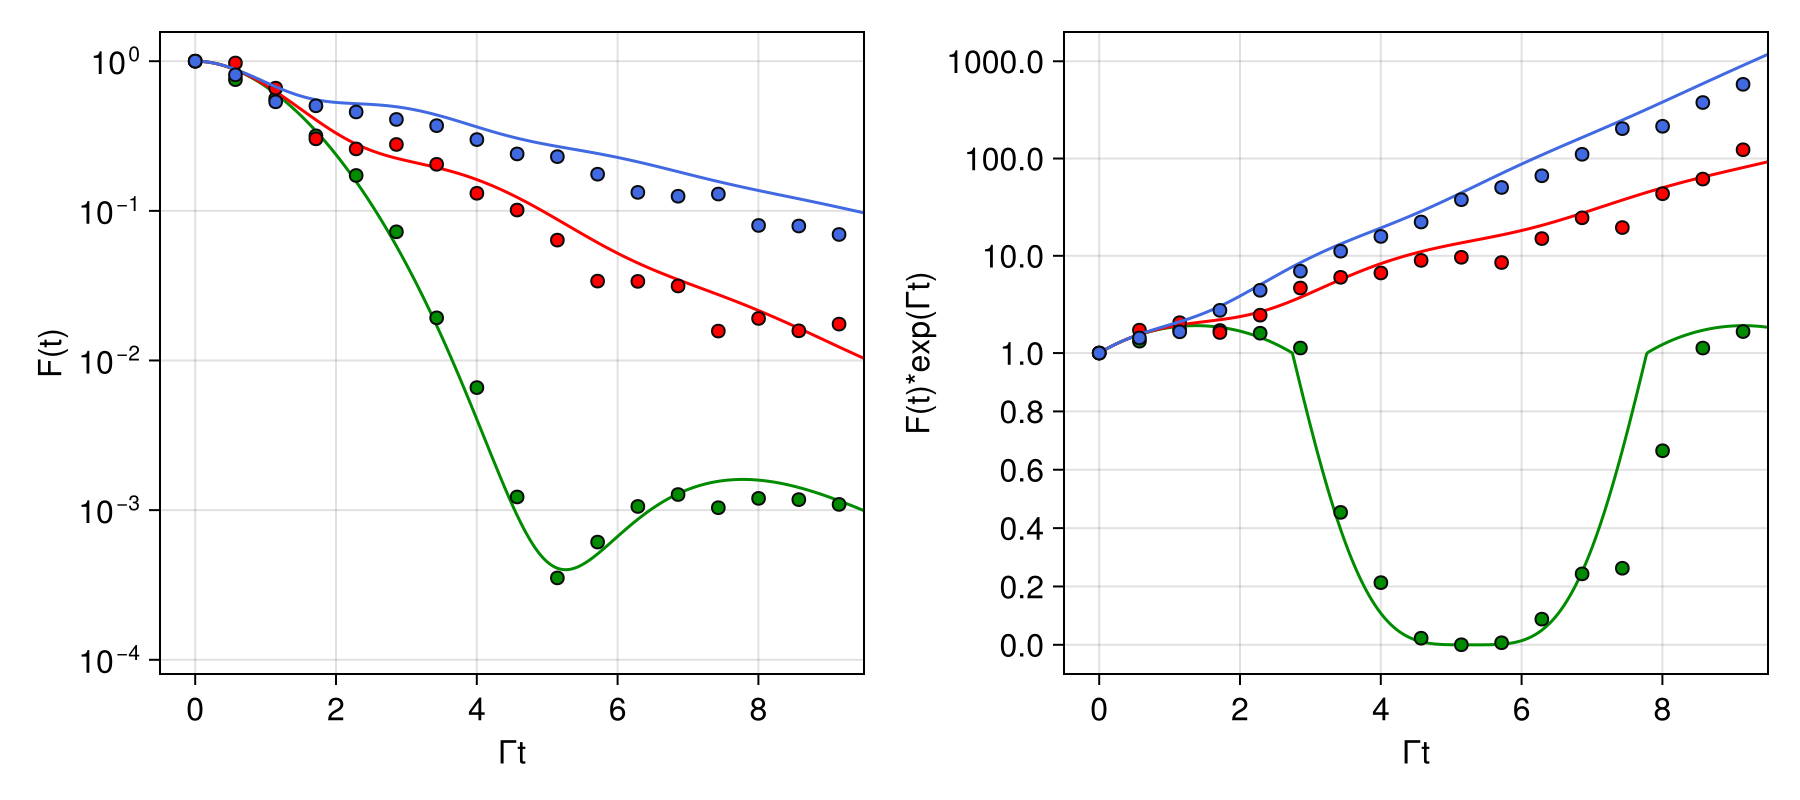

In [251]:
Γ = 2π * 6.065 * 0.5;
Ω = [0.95Γ   0.95Γ   0.95Γ];
V = [0       0.73Γ   1.42Γ];
ϵ = [0.02    0.02    0.02]; # background noise in the experiment

# Load experiment data
files = ["V_0_Omega_0.95_R.csv";
         "V_0.73_Omega_0.95.csv";
         "V_1.42_Omega_0.95.csv"];


t_sim = 0:0.001:0.6;
Ns = 2000;

forward(y) = y <= 1 ? y : 1 + log10(y) / 3
inverse(y) = y <= 1 ? y : 10.0^(3 * (y - 1))
linear_log = Makie.ReversibleScale(forward, inverse; limits=(0, 1000), name=:linear_log)

fig = Figure(size=(900,400), fontsize=16)
ax1 = Axis(fig[1, 1], xlabel="Γt", ylabel="F(t)", yscale = log10, limits=((-0.5,9.5),nothing))
ax2 = Axis(
    fig[1, 2], xlabel="Γt", ylabel="F(t)*exp(Γt)", 
    yscale=linear_log, limits=((-0.5,9.5),(-0.1,2e3)), yticks=[0,0.2,0.4,0.6,0.8, 1, 10, 100, 1000]
)
clrs = [:green4 :red :royalblue :gray];
for i = 1:3

    if i == 1
        t, y_mean, y_std, η = counting_single("data/" * files[i])
        y_mean = y_mean .^ 2
    else
        t, y_mean, y_std, η = counting_double("data/" * files[i])
    end

    R = dynamics_nh(t_sim, model_nh(2), Ω[i], V[i], Γ; exports = (:fidelity, :lognorm))
    R_fid = R[:fidelity] .* exp.(2*R[:lognorm])
    R_corr = ((1 - ϵ[i]) * sqrt.(R_fid) .+ ϵ[i]).^2;

    lines!(ax1,   Γ * t_sim, R_corr, color=clrs[i], label="")
    scatter!(ax1, Γ * t,     y_mean; color=clrs[i], strokecolor=:gray4, strokewidth=1, label="")
    
    lines!(ax2,   Γ * t_sim, R_fid .* exp.(Γ*t_sim), color=clrs[i], label="")
    scatter!(ax2, Γ * t,     ((sqrt.(y_mean) .- ϵ[i])./ (1-ϵ[i])).^2 .* exp.(Γ*t) ; color=clrs[i], strokecolor=:gray4, strokewidth=1, label="")
end

fig

# Figure 4 (B) & S14 (E)

## Comparison of Interaction Models

Calculate the probe-time Loschmidt Echo for $N=2$–$12$ using the full dipolar model, a single-excitation approximation, and a nearest-neighbor model. These data test how spin-wave structure produces the non-monotonic many-body response in Figure 4(B) and Figure S14(E).

Comparing the three models shows when long-range couplings and higher-excitation sectors are needed to reproduce the full dynamics.

Figure 4 (B) contains the results of `C3` interactions in `full_hilbert` space, stored in `LE_full`.

Figure S14 (E) compares the results between `LE_full` and `NN` interactions, `LE_NN`, and `C3` interactions but resitricted to `zero_plus_one` subspace, `LE_1ex`.

In [ ]:
Γ = 2π * 0.7
Ω = 1.2Γ
V_ratios = [0.98, 1.97, 4.11]
N_list = 2:12
t_probe = 1.5

LE_full = zeros(length(V_ratios), length(N_list))
LE_1ex = similar(LE_full)
LE_NN = similar(LE_full)

for (iv, Vr) in enumerate(V_ratios), (iN, Na) in enumerate(N_list)
    V = Vr * Γ
    models = (
        build_model(Na=Na, interaction=:C3, sector=:full_hilbert),
        build_model(Na=Na, interaction=:C3, sector=:zero_plus_one),
        build_model(Na=Na, interaction=:nn, sector=:full_hilbert),
    )
    vals = [dynamics_nh([0.0, t_probe], m, Ω, V, Γ; exports=(:fidelity, :lognorm)) for m in models]
    LE_full[iv, iN] = vals[1][:fidelity][end] * exp(2vals[1][:lognorm][end])
    LE_1ex[iv, iN] = vals[2][:fidelity][end] * exp(2vals[2][:lognorm][end])
    LE_NN[iv, iN] = vals[3][:fidelity][end] * exp(2vals[3][:lognorm][end])
end

jldsave("data/LE_probe_data.jld2";
    Γ = Γ, Ω = Ω, t_probe = t_probe,
    V_ratios = V_ratios, N_list = collect(N_list),    
    LE_full = LE_full, LE_1ex = LE_1ex, LE_NN = LE_NN,
)

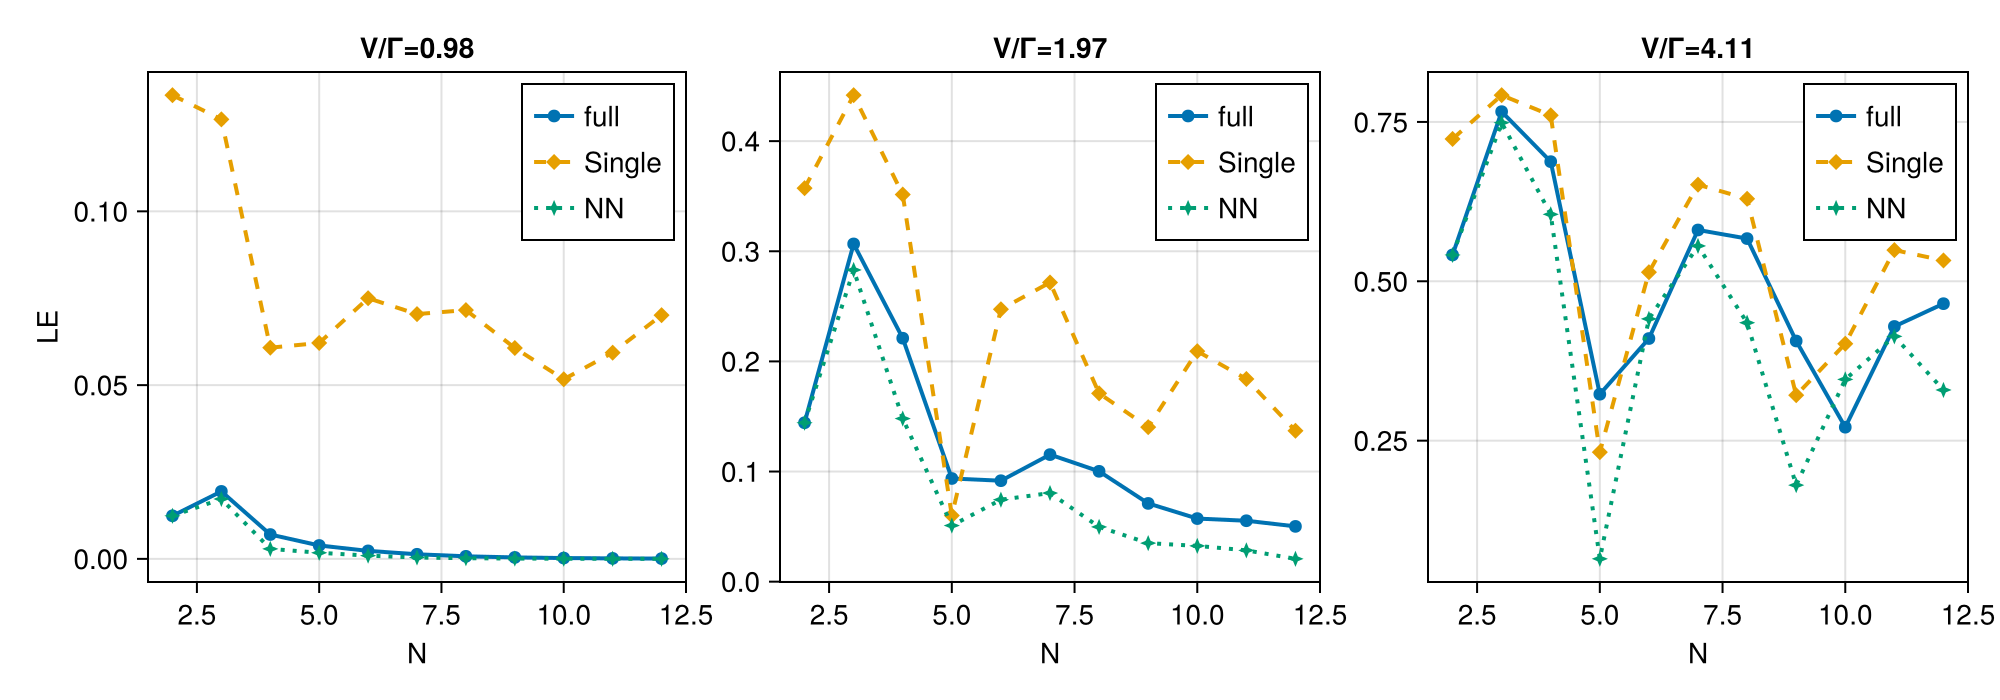

In [4]:
data = load("data/LE_probe_data.jld2")

fig = Figure(size=(1000, 350))
for (iv, Vr) in enumerate(data["V_ratios"])
    ax = Axis(fig[1, iv], xlabel="N", ylabel=iv == 1 ? "LE" : "", title="V/Γ=$(Vr)")
    scatterlines!(ax, data["N_list"], data["LE_full"][iv, :], linewidth=2, marker=:circle, label="full")
    scatterlines!(ax, data["N_list"], data["LE_1ex"][iv, :],  linewidth=2, marker=:diamond, linestyle=:dash, label="Single")
    scatterlines!(ax, data["N_list"], data["LE_NN"][iv, :],   linewidth=2, marker=:star4,   linestyle=:dot, label="NN")
    axislegend(ax)
end
fig

# Figure 5 (D,E) & S13

## Interaction-Dissipation Comparison

Simulate chains of $N=1$–$12$ with interaction only, dissipation only, and both effects present. Saving the fidelity, norm, and excitation populations enables the non-Hermitian many-body blockade to be separated from purely coherent or purely dissipative dynamics.

For a 10-atom chain, compare the normalized Loschmidt Echo produced by interaction alone, dissipation alone, and their coexistence. The time-averaged system-size dependence shows that strong state protection requires both ingredients, as presented in Figure 5(D,E).

NOTE: The result "dynamics_mode_compare.jld2" is too big to upload.

In [ ]:
Γ = 2π * 0.7
Ω = 1.2Γ
V = 4.11Γ
t_list = 0:0.01:10
N_list = 1:12

results = Dict()
for Na in N_list
    model = build_model(Na=Na, interaction=:C3, sector=:full_hilbert)
    results["N=$Na"] = Dict(
        :V_only =>  dynamics_nh(t_list, model, Ω, V, 0Γ; exports=(:fidelity, :lognorm, :populations)),
        :Γ_only =>  dynamics_nh(t_list, model, Ω, 0V, Γ; exports=(:fidelity, :lognorm, :populations)),
        :VΓ_both => dynamics_nh(t_list, model, Ω, V, Γ;  exports=(:fidelity, :lognorm, :populations)),
    )
end

jldsave("data/dynamics_mode_compare.jld2";
    Γ = Γ, Ω = Ω, V = V, N_list = N_list, t_list = t_list, results = results
)

Dict{Symbol, Any} with 2 entries:
  :fidelity => [1.0, 0.993145, 0.973836, 0.945516, 0.912954, 0.881177, 0.854531…
  :t        => 0.0:0.01:10.0

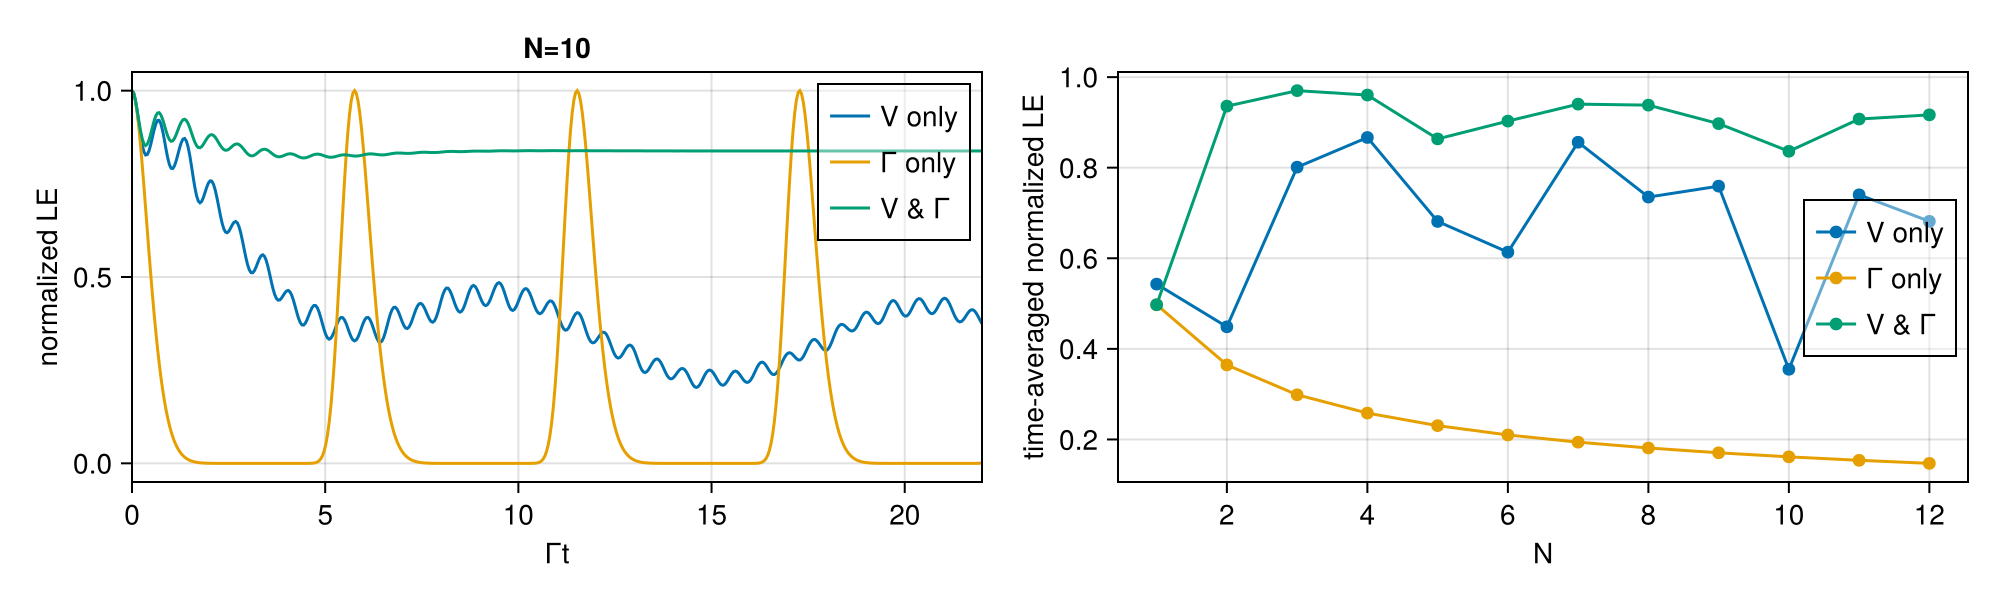

In [5]:
data = load("data/dynamics_mode_compare.jld2")
Γ = data["Γ"]
t_list = data["t_list"]
N_list = data["N_list"]
res_V  = data["results"]["N=10"][:V_only]
res_Γ  = data["results"]["N=10"][:Γ_only]
res_VΓ = data["results"]["N=10"][:VΓ_both]

fig = Figure(size=(1000, 300))
ax = Axis(fig[1, 1], xlabel="Γt", ylabel="normalized LE", title="N=10", limits=((0,22), nothing))
lines!(ax, Γ * res_V[:t],  res_V[:fidelity],  label="V only")
lines!(ax, Γ * res_Γ[:t],  res_Γ[:fidelity],  label="Γ only")
lines!(ax, Γ * res_VΓ[:t], res_VΓ[:fidelity], label="V & Γ")
axislegend(ax, backgroundcolor=(1,1,1,0.4))

ax2 = Axis(fig[1, 2], xlabel="N", ylabel="time-averaged normalized LE", xticks=2:2:12)
meanfid_V  = [mean(data["results"]["N=$N"][:V_only][:fidelity][101:501])  for N in N_list]
meanfid_Γ  = [mean(data["results"]["N=$N"][:Γ_only][:fidelity][101:501])  for N in N_list]
meanfid_VΓ = [mean(data["results"]["N=$N"][:VΓ_both][:fidelity][101:501]) for N in N_list]
scatterlines!(ax2, N_list, meanfid_V , label="V only")
scatterlines!(ax2, N_list, meanfid_Γ , label="Γ only")
scatterlines!(ax2, N_list, meanfid_VΓ, label="V & Γ")
axislegend(ax2, backgroundcolor=(1,1,1,0.4), position=:rc)

fig

## Characterization of the Many-Body Blockade

Analyze excitation probabilities, accumulated single- and double-excitation losses, and their dependence on atom number. The four panels reproduce Figure S13 and demonstrate that the combined interaction-dissipation dynamics suppress exploration of higher-excitation sectors.

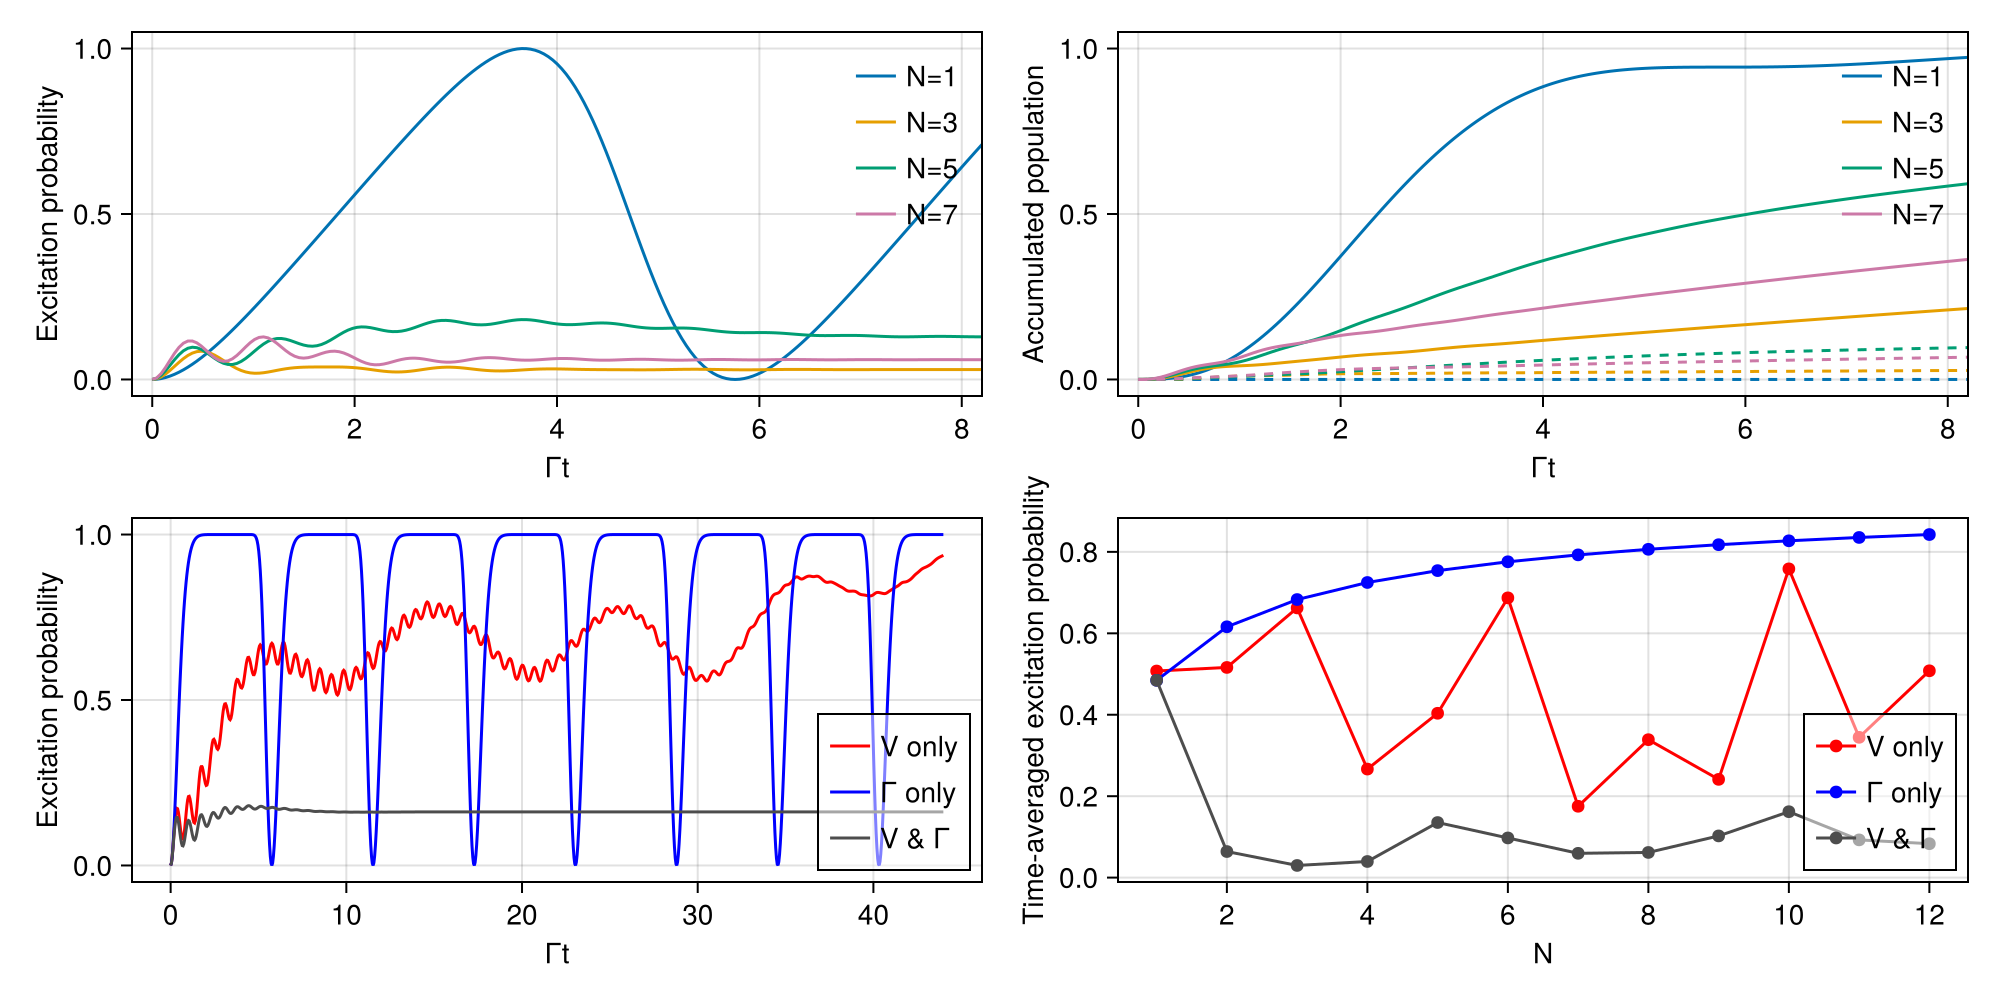

In [6]:
using JLD2, CairoMakie, Statistics

data = load("data/dynamics_mode_compare.jld2")
Γ, t, Ns, results = data["Γ"], data["t_list"], data["N_list"], data["results"]

cases  = [:V_only, :Γ_only, :VΓ_both]
labels = ["V only", "Γ only", "V & Γ"]
colors = [:red, :blue, :gray30]
N_AB, Ncolors = [1, 3, 5, 7], Makie.wong_colors()

sector_population(P, α) = vec(sum(P[count_ones.(0:(size(P, 1)-1)) .== α, :], dims=1))
cumtrapz(t, y) = [0.0; cumsum(diff(t) .* (y[1:end-1] .+ y[2:end]) ./ 2)]

fig = Figure(size=(1000, 500))

axA = Axis(fig[1, 1], limits=((-0.2,8.2),nothing), 
    xlabel="Γt", ylabel="Excitation probability"
)

for (i, N) in enumerate(N_AB)
    F = results["N=$N"][:VΓ_both][:fidelity]
    lines!(axA, Γ .* t, 1 .- F, color=Ncolors[i], label="N=$N")
end
axislegend(axA, framevisible=false)

axB = Axis(fig[1, 2], limits=((-0.2,8.2),nothing), 
    xlabel="Γt", ylabel="Accumulated population"
)

for (i, N) in enumerate(N_AB)
    res = results["N=$N"][:VΓ_both]
    Praw = res[:populations] .* exp.(2 .* res[:lognorm])'
    ρ1 = Γ .* cumtrapz(t, sector_population(Praw, 1))
    ρ2 = 2Γ .* cumtrapz(t, sector_population(Praw, 2))

    lines!(axB, Γ .* t, ρ1, color=Ncolors[i], label="N=$N")
    lines!(axB, Γ .* t, ρ2, color=Ncolors[i], linestyle=:dash)
end
axislegend(axB, framevisible=false)

axC = Axis(fig[2, 1], xlabel="Γt", ylabel="Excitation probability")

for (case, label, color) in zip(cases, labels, colors)
    lines!(axC, Γ .* t, 1 .- results["N=10"][case][:fidelity], color=color, label=label)
end
axislegend(axC, position=:rb, backgroundcolor=(1,1,1,0.5))

axD = Axis(fig[2, 2], xlabel="N", ylabel="Time-averaged excitation probability", xticks=2:2:12)

idx_avg = findall(22 .<= Γ .* t .<= 44)
for (case, label, color) in zip(cases, labels, colors)
    y = [mean(1 .- results["N=$N"][case][:fidelity][idx_avg]) for N in Ns]
    scatterlines!(axD, Ns, y, color=color, label=label)
end
axislegend(axD, position=:rb, backgroundcolor=(1,1,1,0.5))

fig

# Figure S7

## Master-Equation Benchmark

For $N=1$–$4$, simulate the Loschmidt Echo using both the effective non-Hermitian Schrödinger equation and 1000 Monte Carlo wave-function trajectories. This calculation tests the no-jump description against the full open-system dynamics used in Figure S7.


In [36]:
Γ = 1.0
Ω = 1.2Γ
V = 2.0Γ
t = 0:0.01:15
ntraj = 1000

results = Dict{Int, Any}()

for Na in 1:4
    model_nh_i = build_model(Na=Na, levels=:two_level, dynamics=:nonhermitian, interaction=:nn)
    model_me_i = build_model(Na=Na, levels=:three_level, dynamics=:lindblad, interaction=:nn)

    nh = dynamics_nh(t, model_nh_i, Ω, V, Γ; exports=(:fidelity, :lognorm))
    mcwf = dynamics_mcwf(t, model_me_i, Ω, V, Γ; trajectories = ntraj, exports = :fidelity)

    results[Na] = (nh = nh, mcwf = mcwf)
end

jldsave(
    "data/dynamics_mcwf_compare.jld2";
    Γ = Γ, Ω = Ω, V = V, t = collect(t), ntraj = ntraj, results = results
)

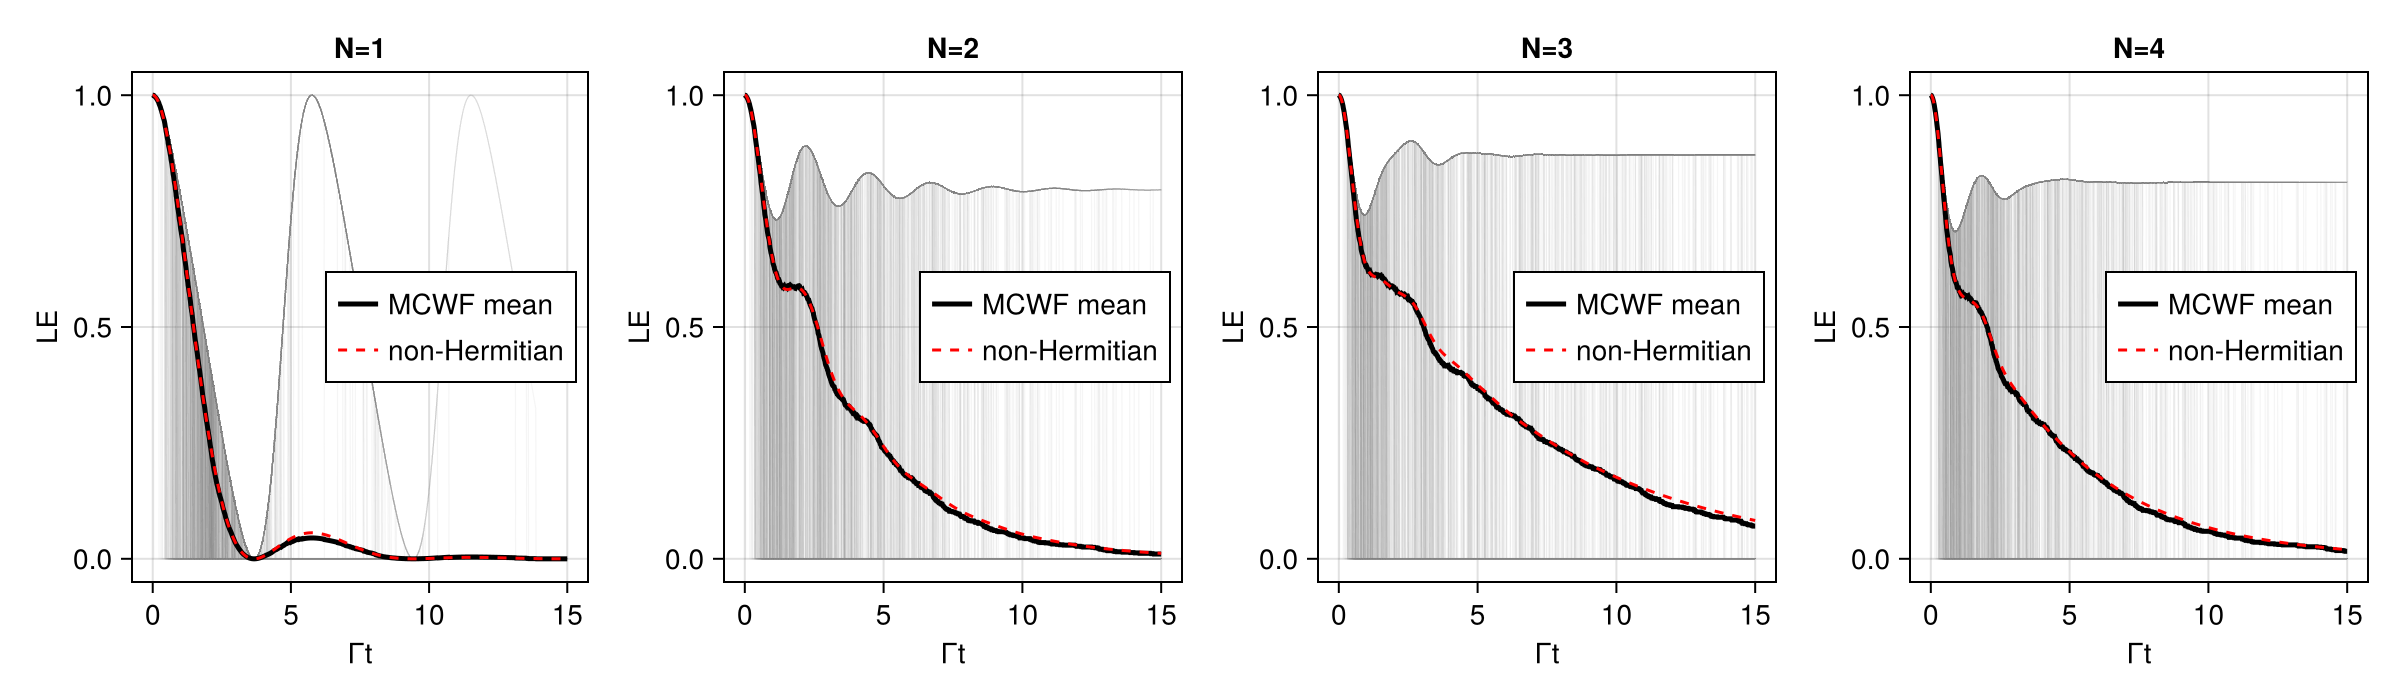

In [7]:
data = load("data/dynamics_mcwf_compare.jld2")

results = data["results"]
Γt = data["Γ"]*data["t"]

fig = Figure(size=(1200, 350))
for Na in 1:4
    ax = Axis(fig[1,Na], xlabel="Γt", ylabel="LE", title="N=$Na")

    for j in 1:data["ntraj"]
        lines!(
            ax, Γt, results[Na].mcwf[:fidelity_trajectories][j, :], 
            color = (:gray, 0.08), linewidth = 0.6
        )
    end
    lines!(ax, Γt, results[Na].mcwf[:fidelity], color = :black, linewidth = 2.5, label = "MCWF mean")
    lines!(ax, Γt, results[Na].nh[:fidelity] .* exp.(2 * results[Na].nh[:lognorm]), color=:red, linestyle=:dash, label="non-Hermitian")
    axislegend(ax, position=:rc)
end
fig

# Figure S11

## Loschmidt Echo and Inverse Participation Ratio

Evolve chains of $N=2$–$12$ in the strongly interacting regime and calculate both the normalized Loschmidt Echo and inverse participation ratio. These observables quantify the restriction of wave-function spreading caused by the non-Hermitian many-body blockade.

In [ ]:
Γ = 1.0
Ω = 1.2Γ
V = 4.1Γ
t = 0:0.01:6π / Γ
N_list = 2:12

LE_normalized = Vector{Float64}[]
IPR = Vector{Float64}[]

for Na in N_list
    model = build_model(Na=Na, interaction=:C3, sector=:full_hilbert)
    res = dynamics_nh(t, model, Ω, V, Γ; exports=(:fidelity, :wavefunction))
    push!(LE_normalized, res[:fidelity])
    push!(IPR, ipr_computational.(eachcol(res[:wavefunction])))
end

jldsave(
    "data/dynamics_ipr.jld2";
    Γ = Γ, Ω = Ω, V = V, t = collect(t), N_list = N_list, LE_normalized = LE_normalized, IPR = IPR
)

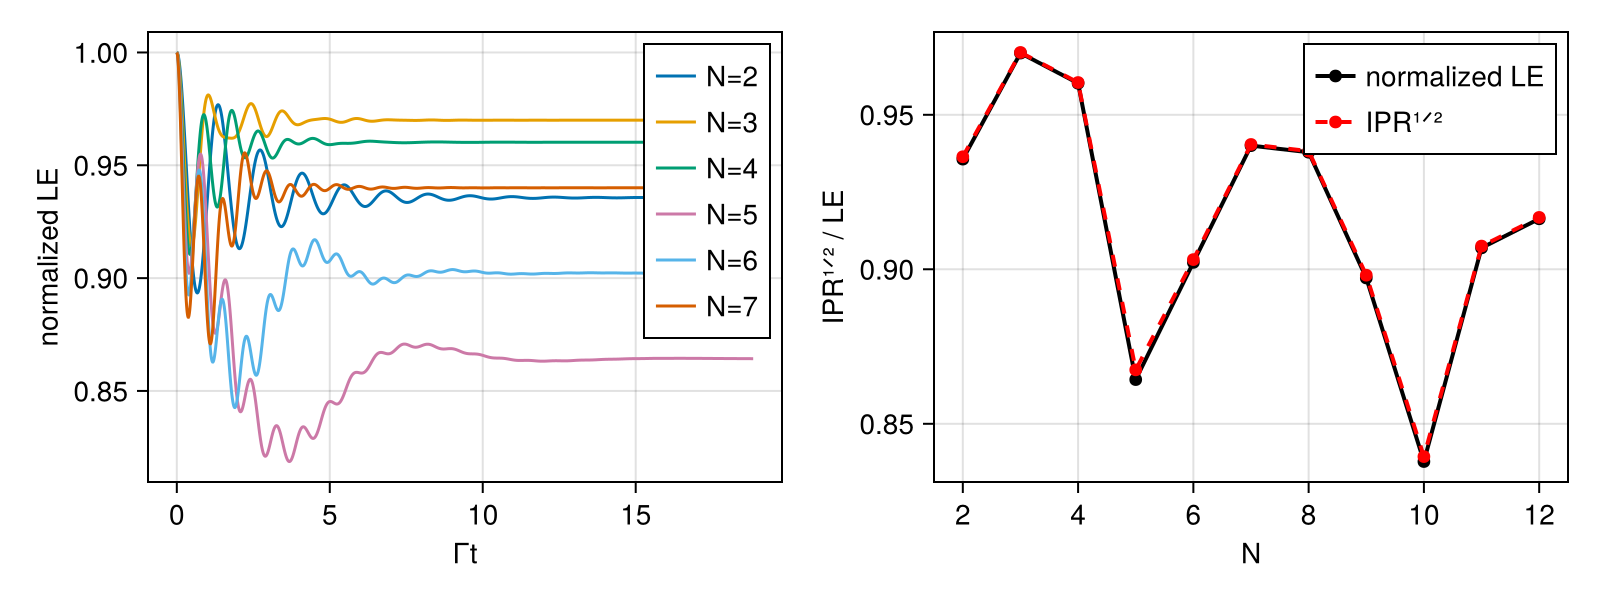

In [8]:
data = load("data/dynamics_ipr.jld2")

fig = Figure(size=(800, 300))
ax1 = Axis(fig[1, 1], xlabel="Γt", ylabel="normalized LE")
ax2 = Axis(fig[1, 2], xlabel="N", ylabel="IPR¹ᐟ² / LE", xticks=2:2:12)

for Na in 2:7
    lines!(ax1, data["Γ"]*data["t"], data["LE_normalized"][Na-1], label="N=$Na")
end

scatterlines!(ax2, data["N_list"], [LE[end] for LE in data["LE_normalized"]], color=:black, label="normalized LE", linewidth=2)
scatterlines!(ax2, data["N_list"], [sqrt.(IPR[end]) for IPR in data["IPR"]], color=:red, label="IPR¹ᐟ²", linestyle=:dash, linewidth=2)
axislegend(ax1)
axislegend(ax2)
fig